# Breast Cancer Classification — Phase 1
## Forecasting and Predictive Analytics Project

### Problem Definition
Breast cancer is one of the most common cancers worldwide. Early and accurate diagnosis
is critical for effective treatment. This project aims to build a predictive classification
model that can distinguish between **benign (non-cancerous)** and **malignant (cancerous)**
tumors based on clinical features extracted from cell samples.

The goal is to apply and compare multiple machine learning algorithms to find the most
accurate and interpretable model for breast cancer classification.

## Dataset Description
**Source:** UCI Machine Learning Repository — Breast Cancer Wisconsin (Original) Dataset  
**Link:** https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Original%29

**Number of Instances:** 699  
**Number of Features:** 9 (excluding ID and target)  
**Target Variable:** Class (0 = Benign, 1 = Malignant)  
**Class Distribution:** ~65% Benign, ~35% Malignant

### Features:
| # | Feature Name | Description |
|---|---|---|
| 1 | Clump Thickness | Thickness of cell clumps (1–10) |
| 2 | Uniformity of Cell Size | Consistency of cell size (1–10) |
| 3 | Uniformity of Cell Shape | Consistency of cell shape (1–10) |
| 4 | Marginal Adhesion | How cells stick together (1–10) |
| 5 | Single Epithelial Cell Size | Size of epithelial cells (1–10) |
| 6 | Bare Nuclei | Nuclei not surrounded by cytoplasm (1–10) |
| 7 | Bland Chromatin | Texture of nucleus (1–10) |
| 8 | Normal Nucleoli | Presence of nucleoli (1–10) |
| 9 | Mitoses | Rate of cell division (1–10) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [2]:
data = pd.read_csv("/content/Breast_Cancer.csv")
data.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB


In [4]:
# Check for missing values
print(data.isnull().sum())

Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [5]:
# drop irrelevant features
data = data.drop(columns=['Sample code number'], axis = 1)

In [6]:
data['Class'].unique()

array([2, 4])

In [7]:
#make target values binary 0,1
data['Class'] = data['Class'].map({2: 0, 4: 1})

In [8]:
X = data.drop(columns = ['Class'])
y = data['Class']

In [9]:
y.unique()

array([0, 1])

In [10]:
X.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [11]:
feature_names = X.columns.tolist()

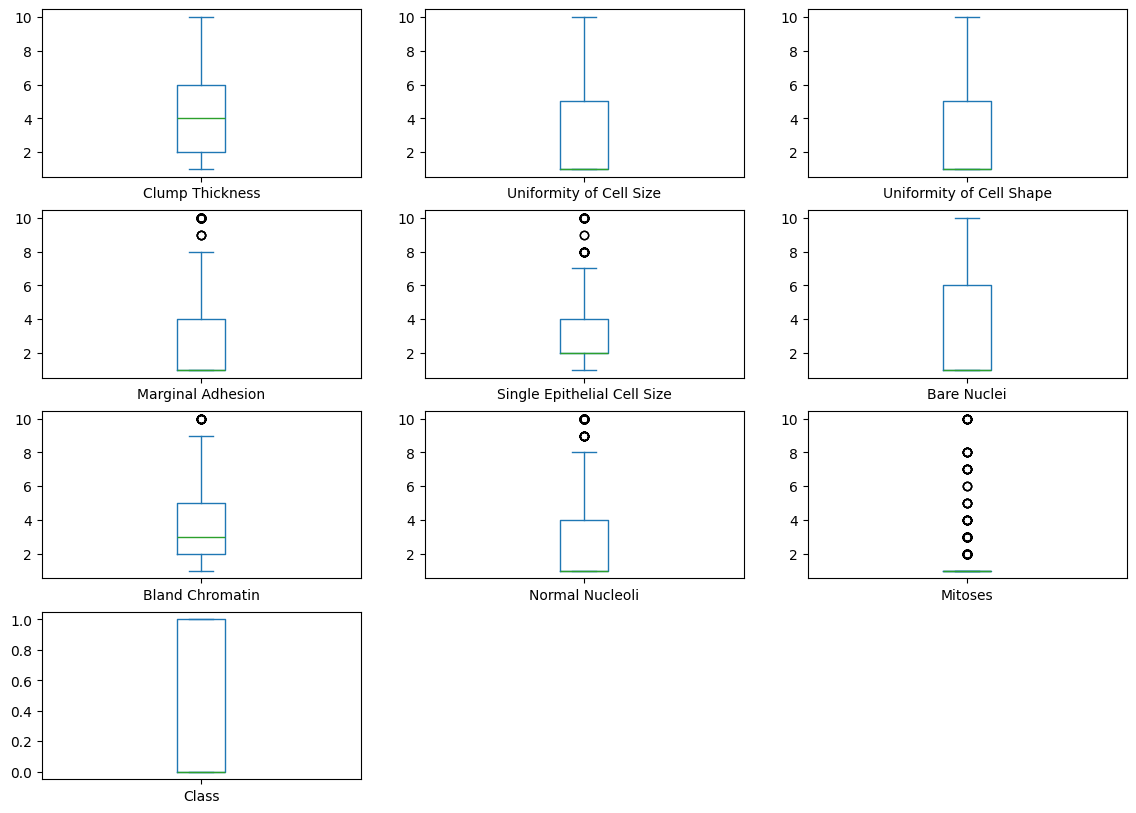

In [12]:
# Boxplots to visualize outliers per feature
data.plot(kind='box', subplots=True, figsize=(14, 10), layout=(4, 3))
plt.show()

"Outliers were retained because in medical datasets they represent real extreme clinical cases, not errors — dropping them would remove critical malignant samples and weaken the model. Feature scaling via StandardScaler was applied to control their influence on the algorithms."

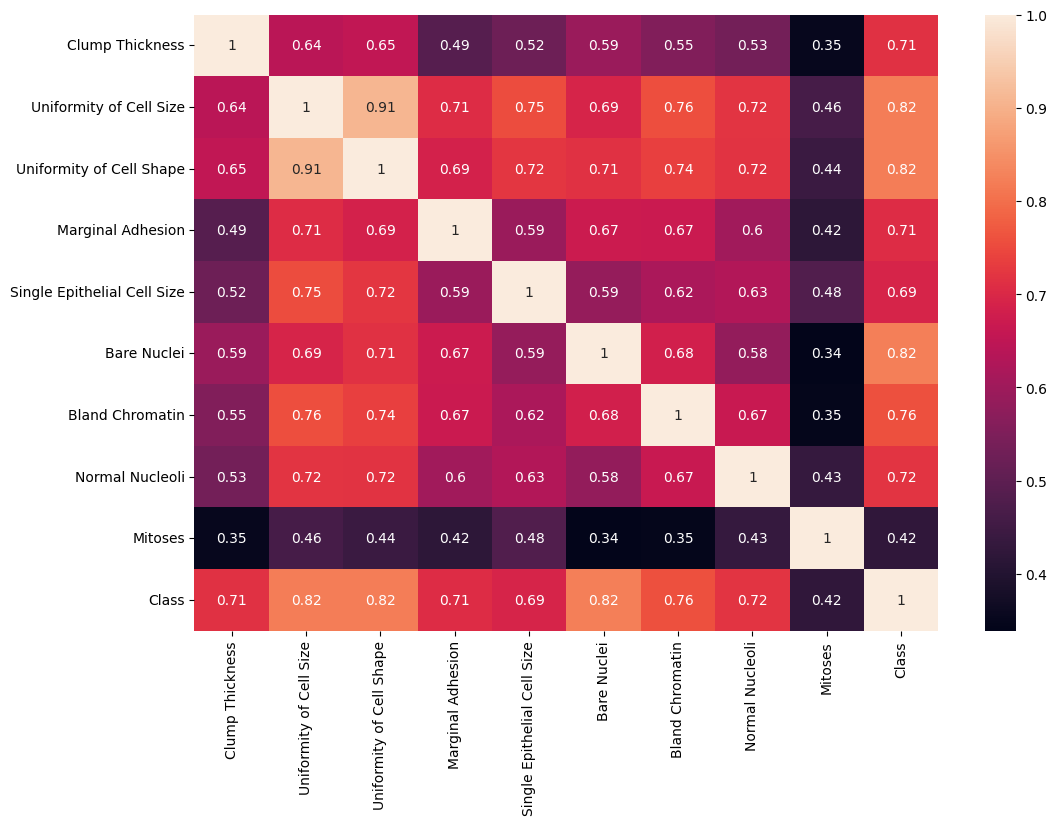

In [13]:
plt.figure(figsize = (12, 8))
sns.heatmap(data.corr(), annot=True)
plt.show()

"The heatmap reveals that Bare Nuclei, Uniformity of Cell Size, and Uniformity of Cell Shape are the strongest predictors of malignancy (r=0.82), while Mitoses shows the weakest correlation. High multicollinearity between Cell Size and Cell Shape (r=0.91) suggests feature redundancy."



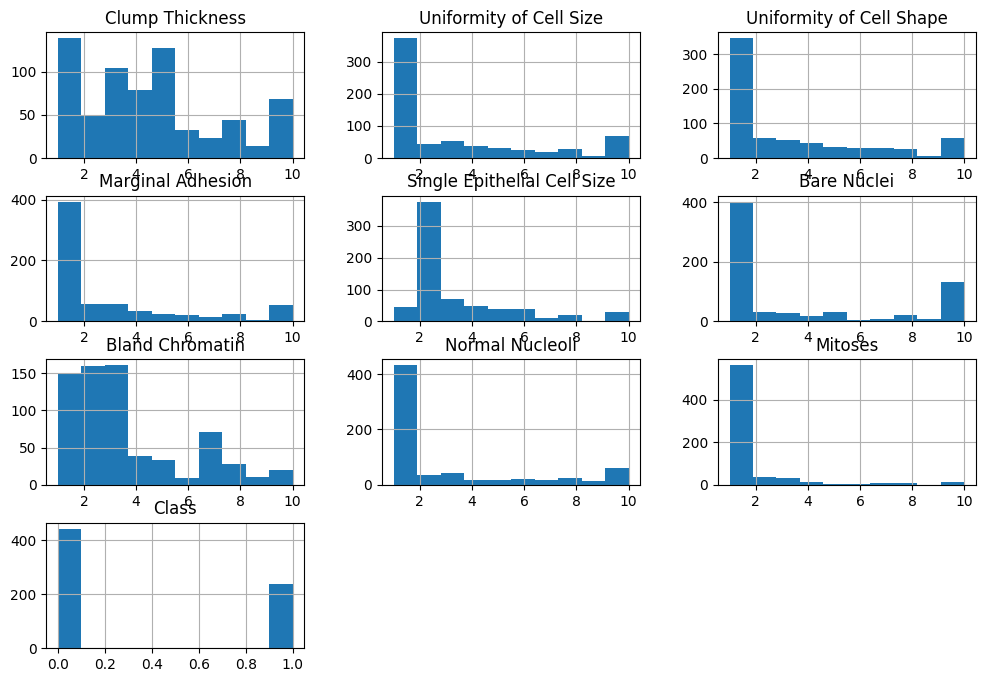

In [14]:
data.hist(figsize = (12, 8))
plt.show()

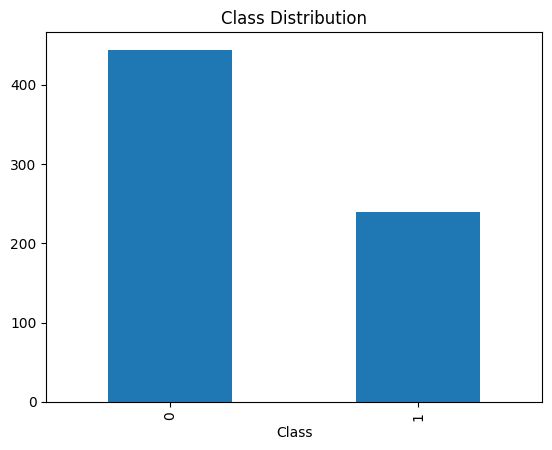

In [15]:
y.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

# ***Algorithms***

# ***Decision Tree***

 Rule-based splits using entropy criterion

In [18]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [19]:
y_pred = tree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred) * 100)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 92.7007299270073

Confusion Matrix:

[[83  4]
 [ 6 44]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        87
           1       0.92      0.88      0.90        50

    accuracy                           0.93       137
   macro avg       0.92      0.92      0.92       137
weighted avg       0.93      0.93      0.93       137



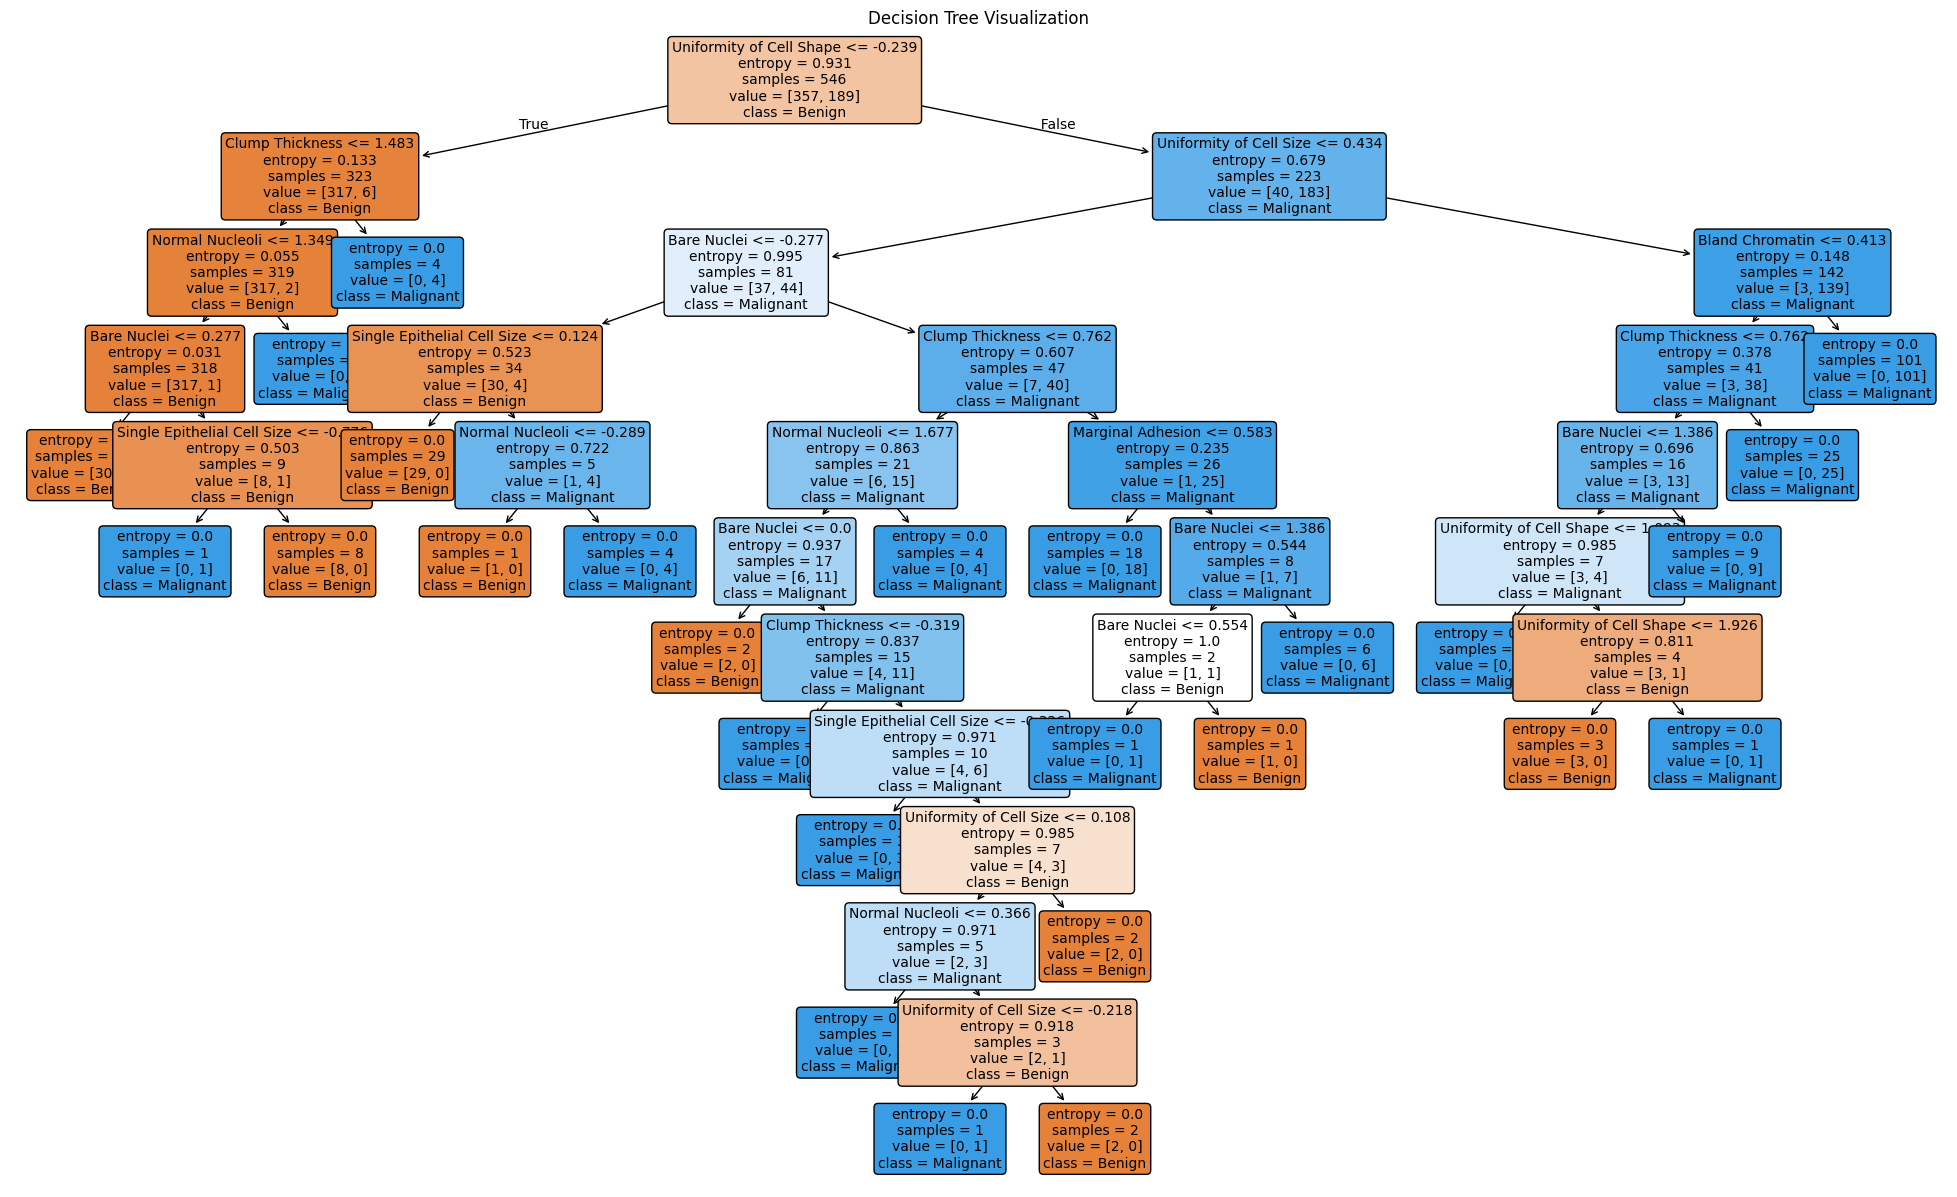

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))
plot_tree(tree,
          feature_names=X.columns.tolist(),
          class_names=['Benign', 'Malignant'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

# ***Naive Bayes***

 Probabilistic classifier based on Bayes' theorem

In [21]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()
NB.fit(X_train, y_train)

GaussianNB()

In [22]:
y_pred = NB.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred) * 100)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 94.16058394160584

Confusion Matrix:

[[83  4]
 [ 4 46]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        87
           1       0.92      0.92      0.92        50

    accuracy                           0.94       137
   macro avg       0.94      0.94      0.94       137
weighted avg       0.94      0.94      0.94       137



# ***Neural Networks***

Multi-layer perceptron with 2 hidden layers (16, 8 neurons)

In [23]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),  # 2 hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)

In [24]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred) * 100)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 97.08029197080292

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        87
           1       1.00      0.92      0.96        50

    accuracy                           0.97       137
   macro avg       0.98      0.96      0.97       137
weighted avg       0.97      0.97      0.97       137


Confusion Matrix:

[[87  0]
 [ 4 46]]


# ***Rule Induction***

Extracts human-readable IF-THEN rules from data

In [25]:
import warnings
warnings.filterwarnings("ignore")
from imodels import RuleFitClassifier
model4 = RuleFitClassifier(random_state=42)
model4.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


RuleFitClassifier(random_state=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
import warnings
warnings.filterwarnings("ignore")
y_pred = model4.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred) * 100)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Accuracy: 96.35036496350365

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        87
           1       0.98      0.92      0.95        50

    accuracy                           0.96       137
   macro avg       0.97      0.95      0.96       137
weighted avg       0.96      0.96      0.96       137


Confusion Matrix:

[[86  1]
 [ 4 46]]


In [27]:
rules_data = []
for rule_obj in model4.rules_:
    rule_text = rule_obj.rule
    # Replace X0, X1, X2... with actual feature names
    for i, name in enumerate(feature_names):
        rule_text = rule_text.replace(f'X{i}', name)

    rules_data.append({
        'rule': rule_text,
        'coef': rule_obj.args[0],
        'support': rule_obj.support
    })

rules = pd.DataFrame(rules_data)
rules = rules[rules['coef'] != 0].sort_values('support', ascending=False)
print(rules.head(10))

                                                                                                                       rule  \
7                                        Clump Thickness <= 1.4829 and Bare Nuclei <= 1.5243 and Normal Nucleoli <= 0.20222   
11                                                               Clump Thickness <= 0.76224 and Normal Nucleoli <= -0.12541   
6   Clump Thickness <= 1.66307 and Uniformity of Cell Size <= 0.43369 and Bare Nuclei <= 0.0 and Normal Nucleoli <= 1.67657   
9                                  Clump Thickness <= 1.12257 and Uniformity of Cell Size <= 0.59655 and Bare Nuclei <= 0.0   
8                                Clump Thickness <= 0.76224 and Marginal Adhesion <= 0.93102 and Bland Chromatin <= 0.01032   
5          Clump Thickness <= 0.9424 and Marginal Adhesion <= 1.80205 and Bare Nuclei <= 0.0 and Normal Nucleoli <= 1.18512   
3                                  Clump Thickness <= 0.76224 and Uniformity of Cell Size <= 0.10798 and Bare N

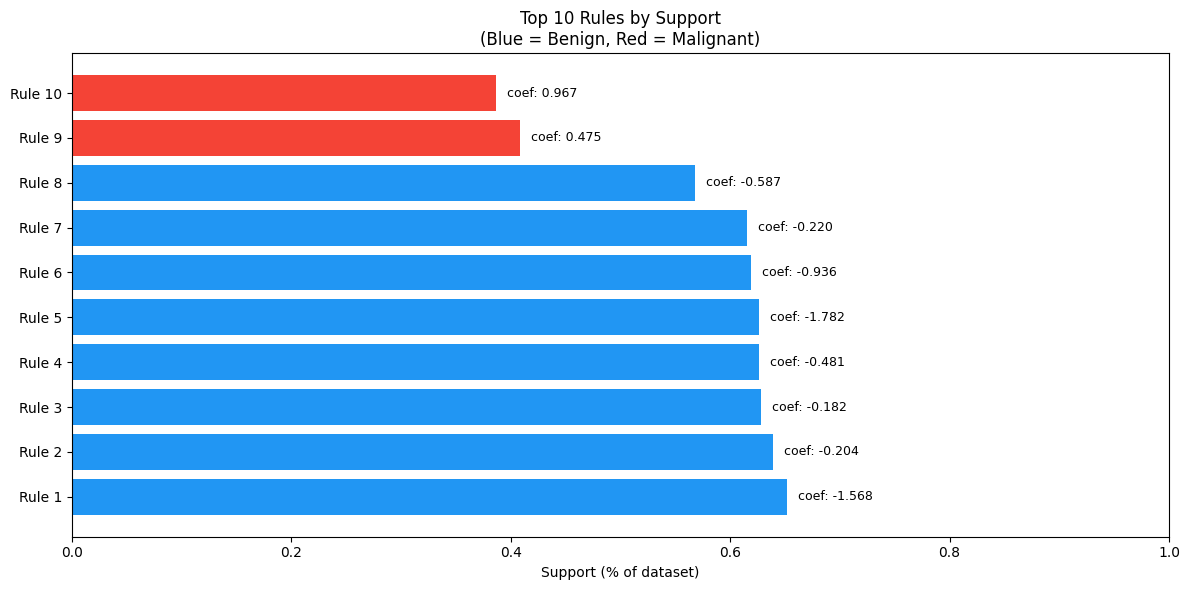

In [28]:
top_rules = rules.head(10).copy()
top_rules['direction'] = top_rules['coef'].apply(lambda x: 'Benign' if x < 0 else 'Malignant')
top_rules['rule_short'] = [f"Rule {i+1}" for i in range(len(top_rules))]

plt.figure(figsize=(12, 6))
colors = ['#2196F3' if d == 'Benign' else '#F44336' for d in top_rules['direction']]
bars = plt.barh(top_rules['rule_short'], top_rules['support'], color=colors)
plt.xlabel('Support (% of dataset)')
plt.title('Top 10 Rules by Support\n(Blue = Benign, Red = Malignant)')
plt.xlim(0, 1)

# Add coef value on each bar
for bar, coef in zip(bars, top_rules['coef']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'coef: {coef:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

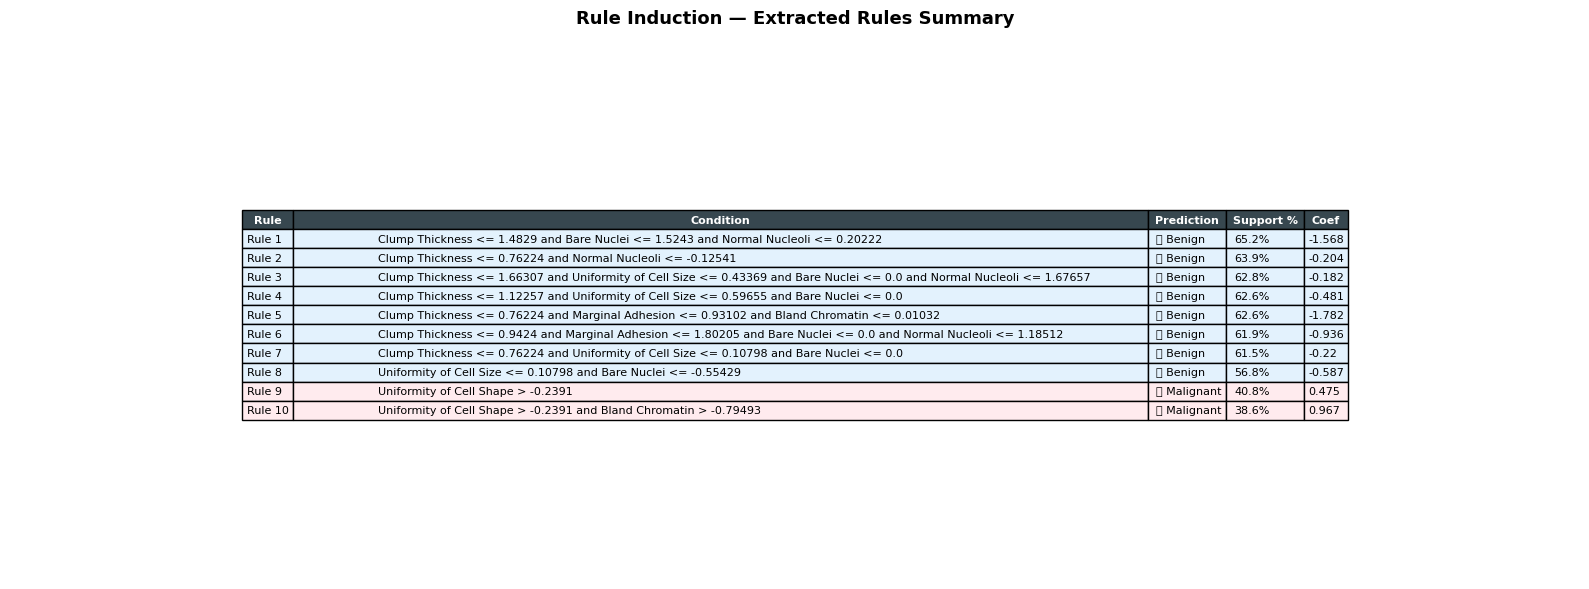

In [29]:
import warnings
warnings.filterwarnings("ignore")
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

top_rules['Rule'] = [f"Rule {i+1}" for i in range(len(top_rules))]
top_rules['Prediction'] = top_rules['coef'].apply(lambda x: '🔵 Benign' if x < 0 else '🔴 Malignant')
top_rules['Support %'] = (top_rules['support'] * 100).round(1).astype(str) + '%'
top_rules['Coef'] = top_rules['coef'].round(3)

display_df = top_rules[['Rule', 'rule', 'Prediction', 'Support %', 'Coef']].rename(columns={'rule': 'Condition'})

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(display_df.columns))))

# Color header
for j in range(len(display_df.columns)):
    table[0, j].set_facecolor('#37474F')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color rows by prediction
for i in range(1, len(display_df) + 1):
    color = '#E3F2FD' if 'Benign' in display_df.iloc[i-1]['Prediction'] else '#FFEBEE'
    for j in range(len(display_df.columns)):
        table[i, j].set_facecolor(color)

plt.title('Rule Induction — Extracted Rules Summary', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

                Accuracy  Precision  Recall  F1-Score
Algorithm                                            
Decision Tree      92.70      91.67    88.0     89.80
Naive Bayes        94.16      92.00    92.0     92.00
Neural Network     97.08     100.00    92.0     95.83
Rule Induction     96.35      97.87    92.0     94.85


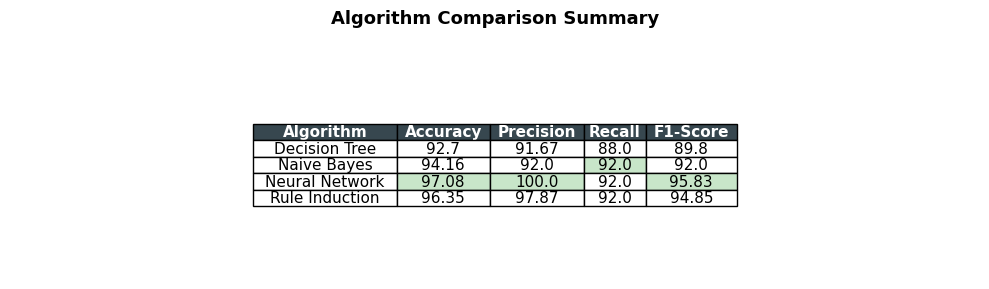

In [30]:
# Collect results
results = {
    'Algorithm': ['Decision Tree', 'Naive Bayes', 'Neural Network', 'Rule Induction'],
    'Accuracy':  [
        accuracy_score(y_test, tree.predict(X_test)) * 100,
        accuracy_score(y_test, NB.predict(X_test)) * 100,
        accuracy_score(y_test, model.predict(X_test)) * 100,
        accuracy_score(y_test, model4.predict(X_test)) * 100
    ]
}

# Add precision, recall, f1 for each
from sklearn.metrics import precision_score, recall_score, f1_score

models_preds = [
    tree.predict(X_test),
    NB.predict(X_test),
    model.predict(X_test),
    model4.predict(X_test)
]

results['Precision'] = [precision_score(y_test, p) * 100 for p in models_preds]
results['Recall']    = [recall_score(y_test, p)    * 100 for p in models_preds]
results['F1-Score']  = [f1_score(y_test, p)        * 100 for p in models_preds]

df_results = pd.DataFrame(results).set_index('Algorithm').round(2)
print(df_results)

#  Summary table
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(
    cellText=df_results.reset_index().values,
    colLabels=['Algorithm'] + list(df_results.columns),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(df_results.columns) + 1)))

# Header styling
for j in range(len(df_results.columns) + 1):
    table[0, j].set_facecolor('#37474F')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Highlight best value in each column green
for col_idx in range(1, len(df_results.columns) + 1):
    col_vals = [float(df_results.reset_index().values[r][col_idx]) for r in range(len(df_results))]
    best_row = col_vals.index(max(col_vals)) + 1
    table[best_row, col_idx].set_facecolor('#C8E6C9')  # green highlight

plt.title('Algorithm Comparison Summary', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ***Conclusion***

"All four algorithms achieved high accuracy on the Breast Cancer dataset, confirming that the features are strongly predictive of malignancy.
- Neural Network achieved the highest accuracy (97.08%) and a perfect Precision (100%), meaning it produced zero false positives — it never incorrectly flagged a benign tumor as malignant, which is critical in medical diagnosis.
- Rule Induction came in second (96.35%) while offering the added advantage of interpretability through human-readable IF-THEN rules.
- Naive Bayes, despite being the simplest probabilistic model, performed competitively at 94.16%.
- Decision Tree had the lowest accuracy (92.70%) but remains the most visually interpretable model through its tree structure.

 Notably, all models achieved the same Recall (92%), meaning they all detected the same proportion of actual malignant cases. The key differentiator between models is therefore Precision and overall Accuracy, where Neural Network leads."

"While Neural Network is the most accurate, Rule Induction is the most suitable for real-world clinical use, as doctors can read and validate its rules directly — making it the preferred choice when model transparency is required over raw performance."

"In cancer diagnosis, Recall is arguably more important than Precision — a false negative (missing a malignant tumor) is far more dangerous than a false positive. All models achieved 92% Recall, meaning 8% of malignant cases were missed. This is an area for future improvement."

In [31]:
import pickle

pickle.dump(tree,   open("decision_tree.sav", "wb"))
pickle.dump(NB,     open("naive_bayes.sav", "wb"))
pickle.dump(model,  open("neural_network.sav", "wb"))
pickle.dump(model4, open("rule_induction.sav", "wb"))
pickle.dump(scaler, open("scaler.sav", "wb"))

print("All models saved!")

All models saved!
